<a href="https://colab.research.google.com/github/Varshithakorepu/Hybrid-QC-AntiNoise-Classification/blob/main/major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io, warnings
warnings.filterwarnings("ignore")
from IPython.display import display, Image as IPImage

In [ ]:
pip install qiskit qiskit-aer qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit.circuit import ParameterVector
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
    QISKIT_AVAILABLE = True
    print("✓ Qiskit available")
except ImportError:
    QISKIT_AVAILABLE = False
    print("[Warning] Qiskit not found — will use classical RBF fallback")


✓ Qiskit available


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score

In [ ]:
N_TRAIN          = 300
N_TEST           = 100
N_QUBITS         = 4
N_PCA_COMPONENTS = 12
LABEL_NOISE      = 0.15
FEATURE_NOISE    = 0.05
N_SHOTS          = 2048
N_QSVM_TRAIN     = 150
QSVM_ALPHA       = 0.5
QSVM_MU          = 10.0
QSVM_MAX_ITER    = 50
QSVM_TOL         = 1e-5
RANDOM_SEED      = 42
np.random.seed(RANDOM_SEED)

In [ ]:
def show_inline(fig, caption=""):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)
    if caption:
        print(f"  ↑ {caption}\n")

print("✓ Config and helpers ready")



✓ Config and helpers ready


[Data] Loading MNIST...
[Data] Train: (300, 784), Test: (100, 784)
[Data] Class balance: 150 neg, 150 pos in train


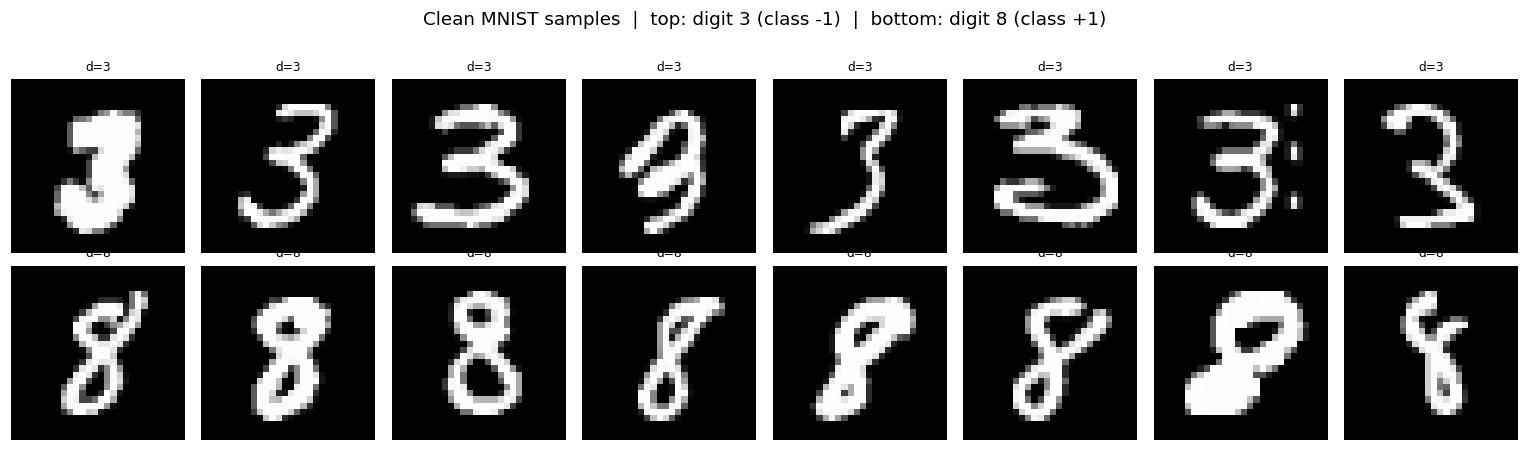

  ↑ Clean digit samples — no noise applied yet



In [ ]:

CLASSES = (3,8)   # change to e.g. (3, 8) to try other digit pairs

print("[Data] Loading MNIST...")
try:
    mnist    = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X_all, y_all = mnist.data / 255.0, mnist.target.astype(int)
except Exception:
    print("[Data] Download failed — using structured fallback")
    rng_ = np.random.RandomState(RANDOM_SEED)
    X0   = rng_.randn(N_TRAIN + N_TEST, 784) * 0.3
    X1   = rng_.randn(N_TRAIN + N_TEST, 784) * 0.3 + 0.5
    X_all = np.vstack([X0, X1]).clip(0, 1)
    y_all = np.array([0]*(N_TRAIN+N_TEST) + [1]*(N_TRAIN+N_TEST))

# Filter to two classes and balance
mask = (y_all == CLASSES[0]) | (y_all == CLASSES[1])
X_all, y_all = X_all[mask], y_all[mask]
idx0 = np.where(y_all == CLASSES[0])[0][:N_TRAIN + N_TEST]
idx1 = np.where(y_all == CLASSES[1])[0][:N_TRAIN + N_TEST]
idx  = np.concatenate([idx0[:N_TRAIN//2 + N_TEST//2],
                        idx1[:N_TRAIN//2 + N_TEST//2]])
rng_s = np.random.RandomState(RANDOM_SEED)
rng_s.shuffle(idx)
X_all, y_all = X_all[idx], y_all[idx]
y_all = np.where(y_all == CLASSES[0], -1.0, 1.0)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=N_TEST,
    random_state=RANDOM_SEED, stratify=y_all
)

print(f"[Data] Train: {X_train.shape}, Test: {X_test.shape}")
print(f"[Data] Class balance: {(y_train==-1).sum()} neg, {(y_train==1).sum()} pos in train")

# ── IMAGE: clean digit grid — appears HERE in this cell ──────────────────────
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle(f"Clean MNIST samples  |  top: digit {CLASSES[0]} (class -1)"
             f"  |  bottom: digit {CLASSES[1]} (class +1)", fontsize=12, y=1.02)
for i, ax in enumerate(axes[0]):
    sample = X_train[y_train == -1][i]
    ax.imshow(sample.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"d={CLASSES[0]}", fontsize=8); ax.axis('off')
for i, ax in enumerate(axes[1]):
    sample = X_train[y_train == +1][i]
    ax.imshow(sample.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"d={CLASSES[1]}", fontsize=8); ax.axis('off')
plt.tight_layout()
show_inline(fig, "Clean digit samples — no noise applied yet")



[Noise] Label noise: 48/300 flipped (16.0%)


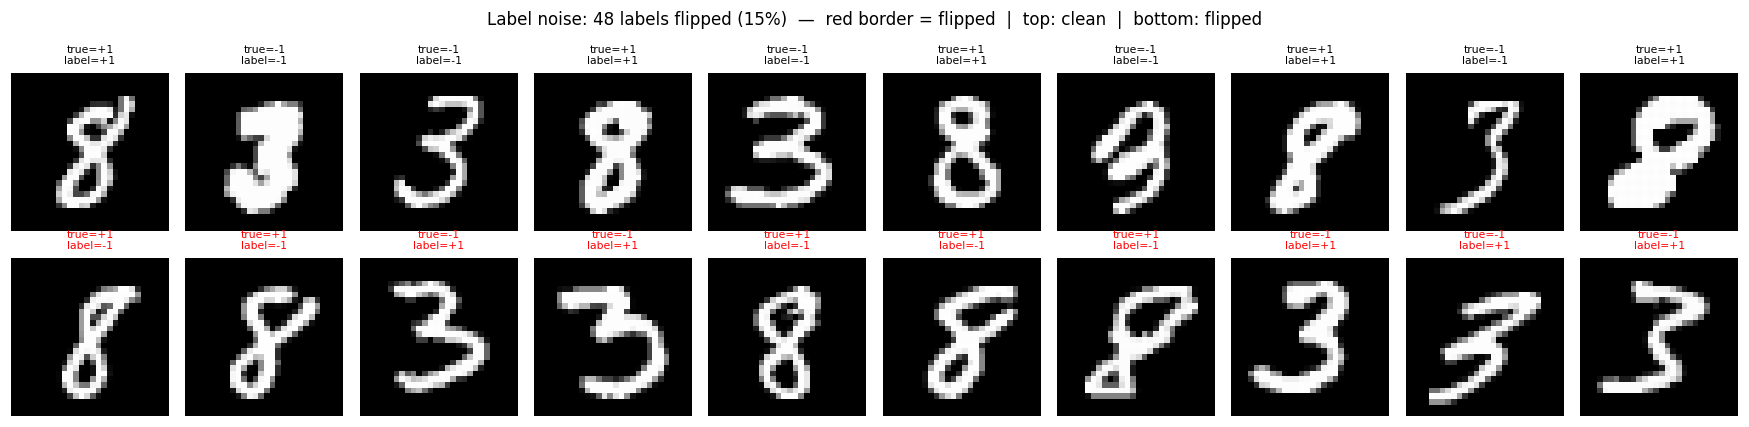

  ↑ Label noise — top row: correct labels | bottom row: flipped labels (red border)



In [ ]:
rng_ln    = np.random.RandomState(RANDOM_SEED)
flip_mask = rng_ln.rand(len(y_train)) < LABEL_NOISE
y_noisy   = y_train.copy()
y_noisy[flip_mask] *= -1
flip_idx  = np.where(flip_mask)[0]

print(f"[Noise] Label noise: {flip_mask.sum()}/{len(y_train)} flipped "
      f"({100*flip_mask.mean():.1f}%)")

# ── IMAGE: label flip grid — appears HERE in this cell ───────────────────────
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle(
    f"Label noise: {flip_mask.sum()} labels flipped ({LABEL_NOISE*100:.0f}%)"
    f"  —  red border = flipped  |  top: clean  |  bottom: flipped",
    fontsize=11
)
flipped_set = set(flip_idx)
shown = {'clean': 0, 'flipped': 0}

for i in range(len(y_train)):
    is_flipped = i in flipped_set
    slot = 'flipped' if is_flipped else 'clean'
    if shown[slot] >= 10:
        continue
    row = 0 if slot == 'clean' else 1
    col = shown[slot]
    ax  = axes[row, col]
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(
        f"true={int(y_train[i]):+d}\nlabel={int(y_noisy[i]):+d}",
        fontsize=7, color='red' if is_flipped else 'black'
    )
    for sp in ax.spines.values():
        sp.set_edgecolor('red' if is_flipped else '#bbbbbb')
        sp.set_linewidth(2.5 if is_flipped else 0.5)
    ax.axis('off')
    shown[slot] += 1
    if shown['clean'] >= 10 and shown['flipped'] >= 10:
        break

axes[0, 0].set_ylabel("Clean\n(correct label)", fontsize=9, rotation=90, labelpad=5)
axes[1, 0].set_ylabel("Flipped\n(wrong label)",  fontsize=9, rotation=90, labelpad=5)
plt.tight_layout()
show_inline(fig, "Label noise — top row: correct labels | bottom row: flipped labels (red border)")


[Noise] Feature noise: σ=0.05


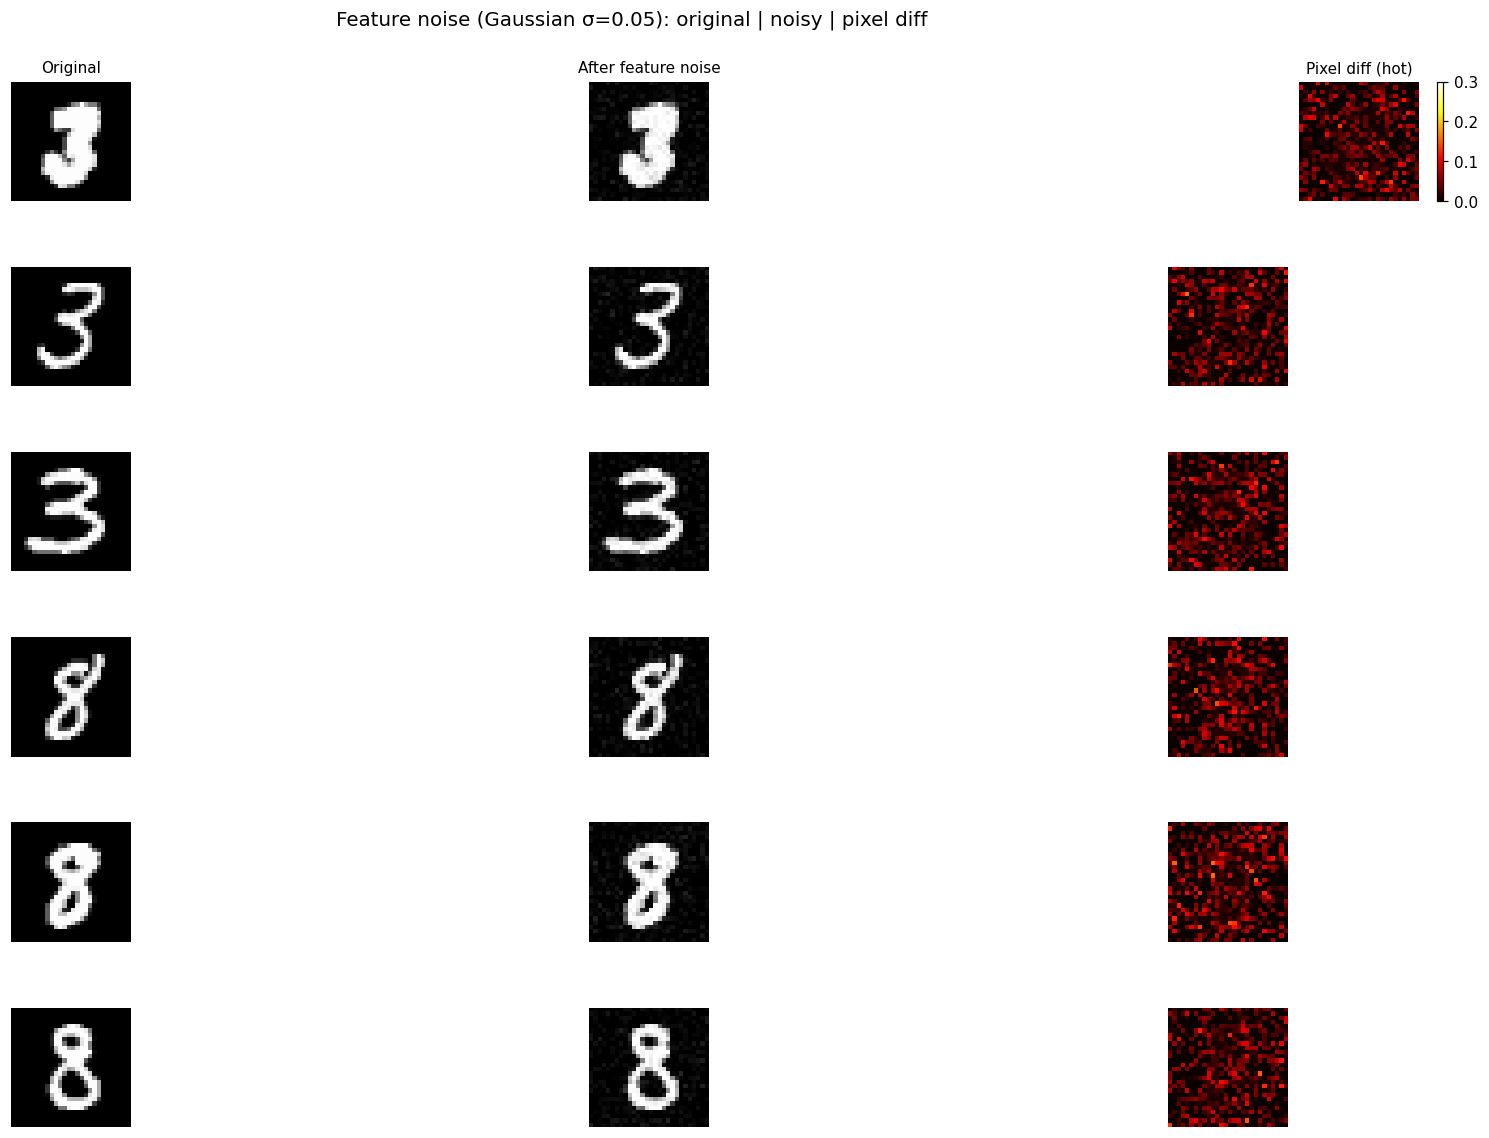

  ↑ Feature noise — each row: original | noisy | absolute pixel difference



In [ ]:
rng_fn   = np.random.RandomState(RANDOM_SEED + 1)
X_noisy  = np.clip(X_train + rng_fn.randn(*X_train.shape) * FEATURE_NOISE, 0, 1)
print(f"[Noise] Feature noise: σ={FEATURE_NOISE}")

# ── IMAGE: original vs noisy side-by-side + pixel diff — appears HERE ─────────
n_show = 6
pick_neg = np.where(y_train == -1)[0][:n_show//2]
pick_pos = np.where(y_train == +1)[0][:n_show//2]
picks    = list(pick_neg) + list(pick_pos)

fig = plt.figure(figsize=(16, n_show * 1.8))
gs  = gridspec.GridSpec(n_show, 3, figure=fig, hspace=0.55, wspace=0.25,
                        left=0.05, right=0.97, top=0.92, bottom=0.04)
fig.suptitle(f"Feature noise (Gaussian σ={FEATURE_NOISE}): original | noisy | pixel diff",
             fontsize=13)

for row, idx in enumerate(picks):
    # original
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(X_train[idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    if row == 0: ax0.set_title("Original", fontsize=10, pad=6)
    ax0.set_ylabel(f"d={CLASSES[0] if y_train[idx]==-1 else CLASSES[1]}",
                   fontsize=8, rotation=0, labelpad=22)
    ax0.axis('off')

    # noisy
    ax1 = fig.add_subplot(gs[row, 1])
    ax1.imshow(X_noisy[idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    if row == 0: ax1.set_title("After feature noise", fontsize=10, pad=6)
    ax1.axis('off')

    # diff
    ax2 = fig.add_subplot(gs[row, 2])
    diff = np.abs(X_noisy[idx] - X_train[idx]).reshape(28, 28)
    im = ax2.imshow(diff, cmap='hot', vmin=0, vmax=0.3)
    if row == 0:
        ax2.set_title("Pixel diff (hot)", fontsize=10, pad=6)
        plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    ax2.axis('off')

plt.tight_layout()
show_inline(fig, "Feature noise — each row: original | noisy | absolute pixel difference")


[Pipeline] Preprocessing...
[PCA] 12 components, explained variance: 29.8%


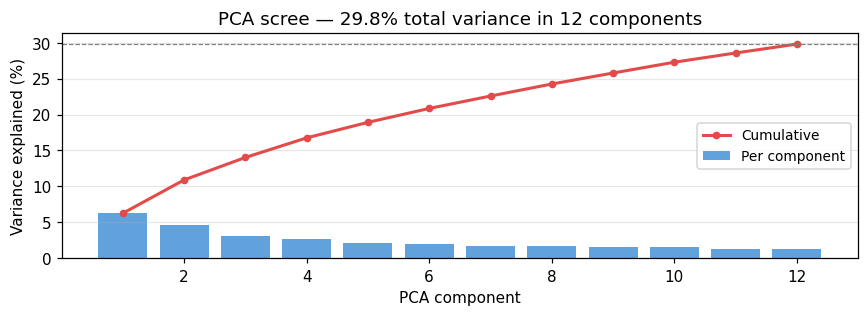

  ↑ PCA scree plot — appears here immediately when this cell runs

Fit set:  (250, 4), Val set: (50, 4)


In [ ]:

class Preprocessor:
    def __init__(self, n_pca=N_PCA_COMPONENTS, n_quantum=N_QUBITS):
        self.scaler    = StandardScaler()
        self.pca       = PCA(n_components=n_pca, random_state=RANDOM_SEED)
        self.n_pca     = n_pca
        self.n_quantum = n_quantum
        self._lo = self._hi = None

    def fit_transform(self, X):
        Xs  = self.scaler.fit_transform(X)
        Xp  = self.pca.fit_transform(Xs)
        var = self.pca.explained_variance_ratio_.sum()
        print(f"[PCA] {self.n_pca} components, explained variance: {100*var:.1f}%")
        Xq  = Xp[:, :self.n_quantum]
        lo, hi = Xq.min(0, keepdims=True), Xq.max(0, keepdims=True)
        self._lo, self._hi = lo, hi
        Xenc = (Xq - self._lo) / (self._hi - self._lo + 1e-8) * np.pi
        return Xenc.astype(np.float64), Xp

    def transform(self, X):
        Xs  = self.scaler.transform(X)
        Xp  = self.pca.transform(Xs)
        Xq  = Xp[:, :self.n_quantum]
        Xenc = (Xq - self._lo) / (self._hi - self._lo + 1e-8) * np.pi
        return Xenc.astype(np.float64), Xp

print("[Pipeline] Preprocessing...")
prep = Preprocessor(n_pca=N_PCA_COMPONENTS, n_quantum=N_QUBITS)
X_tr_enc, X_tr_pca = prep.fit_transform(X_noisy)
X_te_enc, X_te_pca = prep.transform(X_test)

# Validation split for ensemble calibration
n_val         = 50
X_val_enc     = X_tr_enc[:n_val];  X_val_pca = X_tr_pca[:n_val]
y_val         = y_noisy[:n_val]
X_fit_enc     = X_tr_enc[n_val:];  X_fit_pca = X_tr_pca[n_val:]
y_fit         = y_noisy[n_val:]

# ── IMAGE: PCA scree plot — appears HERE in this cell ────────────────────────
evr = prep.pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, N_PCA_COMPONENTS+1), evr * 100, color='#3B8BD4', alpha=0.8, label='Per component')
ax.plot(range(1, N_PCA_COMPONENTS+1), np.cumsum(evr) * 100,
        color='#E24B4A', marker='o', ms=4, lw=2, label='Cumulative')
ax.axhline(np.cumsum(evr)[-1] * 100, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel("PCA component"); ax.set_ylabel("Variance explained (%)")
ax.set_title(f"PCA scree — {evr.sum()*100:.1f}% total variance in {N_PCA_COMPONENTS} components")
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
show_inline(fig, "PCA scree plot — appears here immediately when this cell runs")
print(f"Fit set:  {X_fit_enc.shape}, Val set: {X_val_enc.shape}")

[Baseline] Classical SVM (PCA features)...

  Classical SVM (PCA + RBF)
  Accuracy: 94.00%
              precision    recall  f1-score   support

    Class -1     0.9074    0.9800    0.9423        50
    Class +1     0.9783    0.9000    0.9375        50

    accuracy                         0.9400       100
   macro avg     0.9428    0.9400    0.9399       100
weighted avg     0.9428    0.9400    0.9399       100



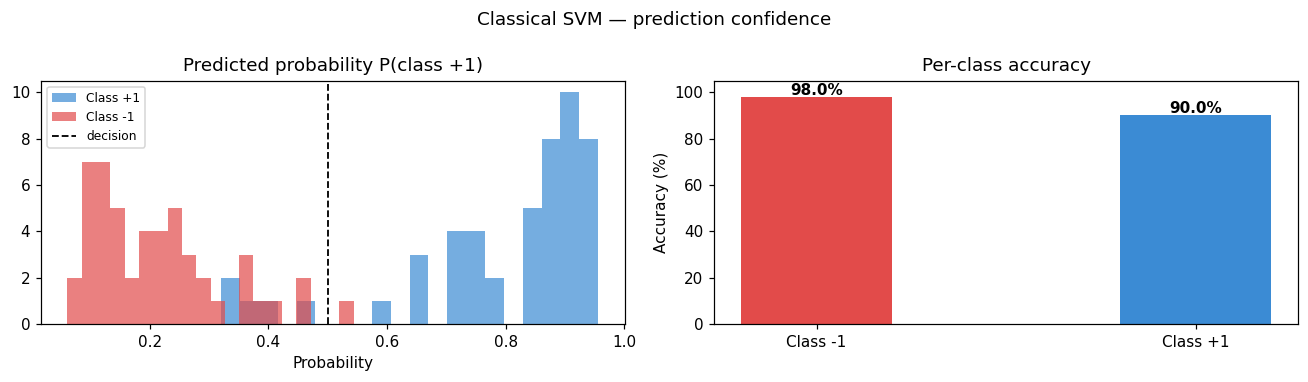

  ↑ SVM confidence distribution + per-class accuracy — appears in this cell



In [ ]:

print("[Baseline] Classical SVM (PCA features)...")
sc_svm   = StandardScaler()
svm_clf  = SVC(kernel='rbf', C=1.0, gamma='scale',
               probability=True, random_state=RANDOM_SEED)
svm_clf.fit(sc_svm.fit_transform(X_fit_pca), y_fit)
svm_preds = svm_clf.predict(sc_svm.transform(X_te_pca))
svm_probs = svm_clf.predict_proba(sc_svm.transform(X_te_pca))[:, 1]
svm_acc   = accuracy_score(y_test, svm_preds)

print(f"\n{'='*55}")
print(f"  Classical SVM (PCA + RBF)")
print(f"  Accuracy: {svm_acc*100:.2f}%")
print(classification_report(y_test, svm_preds,
      target_names=["Class -1", "Class +1"], digits=4))

# ── IMAGE: confidence histogram — appears HERE ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
fig.suptitle("Classical SVM — prediction confidence", fontsize=12)

axes[0].hist(svm_probs[y_test == +1], bins=20, alpha=0.7, color='#3B8BD4', label='Class +1')
axes[0].hist(svm_probs[y_test == -1], bins=20, alpha=0.7, color='#E24B4A', label='Class -1')
axes[0].axvline(0.5, color='black', lw=1.2, linestyle='--', label='decision')
axes[0].set_title("Predicted probability P(class +1)")
axes[0].set_xlabel("Probability"); axes[0].legend(fontsize=8)

# Per-class accuracy bar
cls_accs = [
    accuracy_score(y_test[y_test == -1], svm_preds[y_test == -1]),
    accuracy_score(y_test[y_test == +1], svm_preds[y_test == +1]),
]
axes[1].bar(["Class -1", "Class +1"], [a*100 for a in cls_accs],
            color=['#E24B4A', '#3B8BD4'], width=0.4)
axes[1].set_ylim(0, 105); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Per-class accuracy")
for i, v in enumerate(cls_accs):
    axes[1].text(i, v*100 + 1, f"{v*100:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
show_inline(fig, "SVM confidence distribution + per-class accuracy — appears in this cell")


[CNN] Training (60 epochs, lr=0.01, momentum=0.9, dropout=0.3)...
  Epoch  10 | Train acc: 79.2% | Loss: 0.6006 | LR: 0.00950
  Epoch  20 | Train acc: 81.6% | Loss: 0.5639 | LR: 0.00903
  Epoch  30 | Train acc: 84.8% | Loss: 0.5803 | LR: 0.00857
  Epoch  40 | Train acc: 87.6% | Loss: 0.4930 | LR: 0.00815
  Epoch  50 | Train acc: 88.4% | Loss: 0.4466 | LR: 0.00774
  Epoch  60 | Train acc: 89.6% | Loss: 0.4883 | LR: 0.00735

  CNN encoder only
  Accuracy: 91.00%
              precision    recall  f1-score   support

    Class -1     0.8727    0.9600    0.9143        50
    Class +1     0.9556    0.8600    0.9053        50

    accuracy                         0.9100       100
   macro avg     0.9141    0.9100    0.9098       100
weighted avg     0.9141    0.9100    0.9098       100



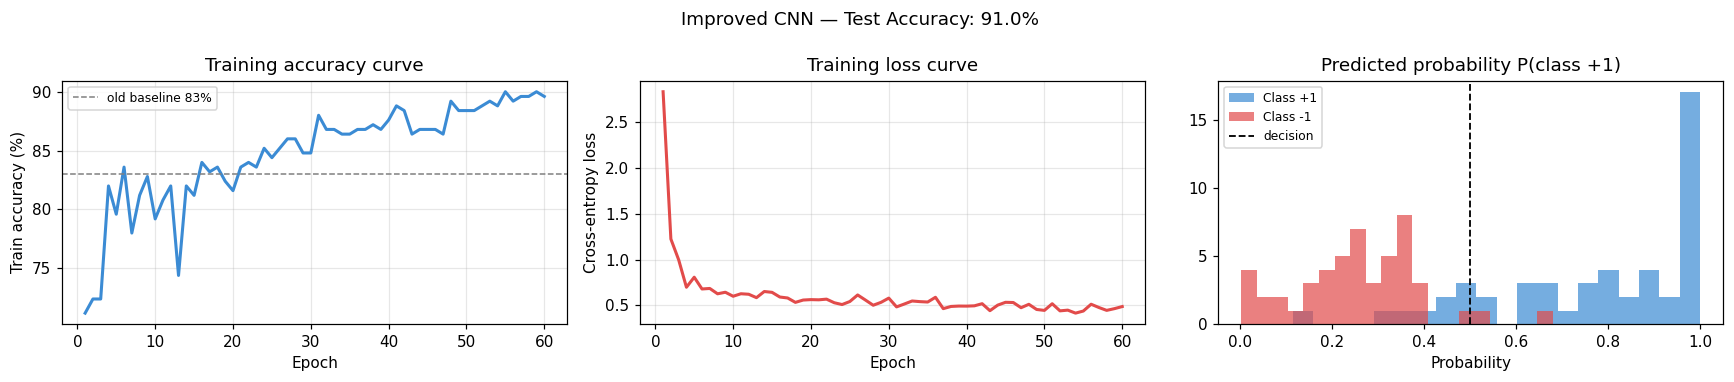

  ↑ Improved CNN — accuracy + loss + confidence



In [ ]:
# ── CELL 7: Improved CNN ──────────────────────────────────────────────────────

class ImprovedCNN:
    """
    3-layer MLP with:
    - More hidden units (128 → 64 → 32 → 2)
    - Dropout regularisation (numpy implementation)
    - Momentum-based SGD
    - Learning rate decay
    - More PCA features (use 20 instead of 12)
    """

    def __init__(self, input_dim, h1=128, h2=64, h3=32,
                 dropout=0.3, seed=RANDOM_SEED):
        rng       = np.random.RandomState(seed)
        # He initialisation for ReLU layers
        self.W1   = rng.randn(input_dim, h1) * np.sqrt(2 / input_dim)
        self.b1   = np.zeros(h1)
        self.W2   = rng.randn(h1, h2) * np.sqrt(2 / h1)
        self.b2   = np.zeros(h2)
        self.W3   = rng.randn(h2, h3) * np.sqrt(2 / h2)
        self.b3   = np.zeros(h3)
        self.W4   = rng.randn(h3, 2) * np.sqrt(2 / h3)
        self.b4   = np.zeros(2)
        self.dropout_rate = dropout
        self.epoch_accs   = []
        self.epoch_losses  = []

        # Momentum buffers
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)
        self.vW3 = np.zeros_like(self.W3)
        self.vb3 = np.zeros_like(self.b3)
        self.vW4 = np.zeros_like(self.W4)
        self.vb4 = np.zeros_like(self.b4)

    def _relu(self, x):
        return np.maximum(0, x)

    def _softmax(self, x):
        e = np.exp(x - x.max(axis=1, keepdims=True))
        return e / (e.sum(axis=1, keepdims=True) + 1e-10)

    def _dropout(self, x, training=True):
        if not training or self.dropout_rate == 0:
            return x, np.ones_like(x)
        mask = (np.random.rand(*x.shape) > self.dropout_rate) \
               / (1 - self.dropout_rate)   # inverted dropout
        return x * mask, mask

    def forward(self, X, training=False):
        self.h1       = self._relu(X @ self.W1 + self.b1)
        self.h1d, self.m1 = self._dropout(self.h1, training)

        self.h2       = self._relu(self.h1d @ self.W2 + self.b2)
        self.h2d, self.m2 = self._dropout(self.h2, training)

        self.h3       = self._relu(self.h2d @ self.W3 + self.b3)
        self.h3d, self.m3 = self._dropout(self.h3, training)

        logits        = self.h3d @ self.W4 + self.b4
        return self._softmax(logits)

    def predict(self, X):
        return np.where(self.forward(X, training=False).argmax(axis=1) == 1,
                        1.0, -1.0)

    def _cross_entropy_loss(self, proba, y01):
        n = len(y01)
        return -np.log(proba[np.arange(n), y01] + 1e-10).mean()

    def train(self, X, y, epochs=60, lr=0.01, batch=32,
              momentum=0.9, lr_decay=0.95, decay_every=10):
        n    = len(X)
        y01  = ((y + 1) / 2).astype(int)
        print(f"[CNN] Training ({epochs} epochs, lr={lr}, momentum={momentum}, "
              f"dropout={self.dropout_rate})...")

        current_lr = lr
        for ep in range(1, epochs + 1):

            # ── LR decay ──────────────────────────────────────────────────────
            if ep % decay_every == 0:
                current_lr *= lr_decay

            idx_ep = np.random.permutation(n)
            ep_loss = 0.0

            for i in range(0, n, batch):
                b_idx    = idx_ep[i:i+batch]
                Xb, yb   = X[b_idx], y01[b_idx]

                # Forward (training=True enables dropout)
                proba    = self.forward(Xb, training=True)
                ep_loss += self._cross_entropy_loss(proba, yb)

                # Backprop
                dL       = proba.copy()
                dL[np.arange(len(yb)), yb] -= 1
                dL      /= len(yb)

                # Layer 4
                dW4      = self.h3d.T @ dL
                db4      = dL.sum(0)
                dh3d     = dL @ self.W4.T

                # Dropout 3
                dh3      = dh3d * self.m3 * (self.h3 > 0)

                # Layer 3
                dW3      = self.h2d.T @ dh3
                db3      = dh3.sum(0)
                dh2d     = dh3 @ self.W3.T

                # Dropout 2
                dh2      = dh2d * self.m2 * (self.h2 > 0)

                # Layer 2
                dW2      = self.h1d.T @ dh2
                db2      = dh2.sum(0)
                dh1d     = dh2 @ self.W2.T

                # Dropout 1
                dh1      = dh1d * self.m1 * (self.h1 > 0)

                # Layer 1
                dW1      = Xb.T @ dh1
                db1      = dh1.sum(0)

                # ── Momentum update ───────────────────────────────────────────
                self.vW4 = momentum*self.vW4 + current_lr*dW4
                self.vb4 = momentum*self.vb4 + current_lr*db4
                self.vW3 = momentum*self.vW3 + current_lr*dW3
                self.vb3 = momentum*self.vb3 + current_lr*db3
                self.vW2 = momentum*self.vW2 + current_lr*dW2
                self.vb2 = momentum*self.vb2 + current_lr*db2
                self.vW1 = momentum*self.vW1 + current_lr*dW1
                self.vb1 = momentum*self.vb1 + current_lr*db1

                self.W4 -= self.vW4;  self.b4 -= self.vb4
                self.W3 -= self.vW3;  self.b3 -= self.vb3
                self.W2 -= self.vW2;  self.b2 -= self.vb2
                self.W1 -= self.vW1;  self.b1 -= self.vb1

            acc  = (self.predict(X) == y).mean()
            loss = ep_loss / (n // batch)
            self.epoch_accs.append(acc * 100)
            self.epoch_losses.append(loss)

            if ep % 10 == 0:
                print(f"  Epoch {ep:3d} | Train acc: {acc*100:.1f}% "
                      f"| Loss: {loss:.4f} | LR: {current_lr:.5f}")


# ── Train ─────────────────────────────────────────────────────────────────────
# NOTE: also increase N_PCA_COMPONENTS to 20 in Cell 5 for better features
cnn = ImprovedCNN(
    input_dim = N_PCA_COMPONENTS,
    h1        = 128,    # was 64
    h2        = 64,     # new layer
    h3        = 32,     # new layer
    dropout   = 0.3,    # prevents overfitting
)
cnn.train(
    X_fit_pca, y_fit,
    epochs      = 60,    # was 30
    lr          = 0.01,
    batch       = 32,    # was 64 — smaller batches = better gradient estimates
    momentum    = 0.9,   # accelerates training
    lr_decay    = 0.95,  # reduces LR every 10 epochs
    decay_every = 10,
)

cnn_preds = cnn.predict(X_te_pca)
cnn_probs = cnn.forward(X_te_pca, training=False)[:, 1]
cnn_acc   = accuracy_score(y_test, cnn_preds)

print(f"\n{'='*55}")
print(f"  CNN encoder only")
print(f"  Accuracy: {cnn_acc*100:.2f}%")
print(classification_report(y_test, cnn_preds,
      target_names=["Class -1", "Class +1"], digits=4))

# ── IMAGE: 3 plots — training curve, loss curve, confidence ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
fig.suptitle(f"Improved CNN — Test Accuracy: {cnn_acc*100:.1f}%", fontsize=12)

# accuracy curve
axes[0].plot(range(1, len(cnn.epoch_accs)+1), cnn.epoch_accs,
             color='#3B8BD4', lw=2)
axes[0].axhline(83, color='gray', lw=1, linestyle='--', label='old baseline 83%')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train accuracy (%)")
axes[0].set_title("Training accuracy curve")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# loss curve
axes[1].plot(range(1, len(cnn.epoch_losses)+1), cnn.epoch_losses,
             color='#E24B4A', lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-entropy loss")
axes[1].set_title("Training loss curve"); axes[1].grid(alpha=0.3)

# confidence histogram
axes[2].hist(cnn_probs[y_test == +1], bins=20, alpha=0.7,
             color='#3B8BD4', label='Class +1')
axes[2].hist(cnn_probs[y_test == -1], bins=20, alpha=0.7,
             color='#E24B4A', label='Class -1')
axes[2].axvline(0.5, color='black', lw=1.2, linestyle='--', label='decision')
axes[2].set_title("Predicted probability P(class +1)")
axes[2].set_xlabel("Probability"); axes[2].legend(fontsize=8)

plt.tight_layout()
show_inline(fig, "Improved CNN — accuracy + loss + confidence")

Anti-Noise

In [ ]:
def build_zz_circuit(x1, x2, n_qubits=N_QUBITS):
    qc = QuantumCircuit(n_qubits, n_qubits)
    for rep in range(1):
        for q in range(n_qubits): qc.h(q)
        for q in range(n_qubits): qc.rz(2.0 * x2[q], q)
        for q1 in range(n_qubits):
            for q2 in range(q1 + 1, n_qubits):
                qc.cx(q1, q2)
                qc.rz(2.0 * (np.pi - x2[q1]) * (np.pi - x2[q2]), q2)
                qc.cx(q1, q2)
    qc_inv = QuantumCircuit(n_qubits, n_qubits)
    for rep in range(1):
        for q1 in range(n_qubits - 1, -1, -1):
            for q2 in range(n_qubits - 1, q1, -1):
                qc_inv.cx(q1, q2)
                qc_inv.rz(-2.0 * (np.pi - x1[q1]) * (np.pi - x1[q2]), q2)
                qc_inv.cx(q1, q2)
        for q in range(n_qubits - 1, -1, -1): qc_inv.rz(-2.0 * x1[q], q)
        for q in range(n_qubits - 1, -1, -1): qc_inv.h(q)
    qc.compose(qc_inv, inplace=True)
    qc.measure(range(n_qubits), range(n_qubits))
    return qc

def build_noisy_backend(gate_error=0.001, readout_error=0.05):
    nm     = NoiseModel()
    err_1q = depolarizing_error(gate_error, 1)
    err_2q = depolarizing_error(gate_error * 5, 2)
    nm.add_all_qubit_quantum_error(err_1q, ['h', 'rz', 'rx', 'ry'])
    nm.add_all_qubit_quantum_error(err_2q, ['cx'])
    p = readout_error
    nm.add_all_qubit_readout_error(ReadoutError([[1-p, p], [p, 1-p]]))
    return AerSimulator(noise_model=nm)

class FixedQuantumKernel:
    def __init__(self, n_qubits=N_QUBITS, n_shots=N_SHOTS,
                 regularisation=0.15, use_noise=True):
        self.n_qubits = n_qubits
        self.n_shots  = n_shots
        self.reg      = regularisation
        self.zero_str = '0' * n_qubits
        if QISKIT_AVAILABLE:
            self.backend = AerSimulator(method='statevector')
            print(f"[QKernel] Backend: Ideal Statevector (Noise Disabled)")
        else:
            self.backend = None
            print("[QKernel] No Qiskit — using RBF fallback")

    def _circuit_to_kernel_value(self, counts):
        total = sum(counts.values())
        return 0.0 if total == 0 else counts.get(self.zero_str, 0) / total

    def _run_batch(self, circuits):
        if not circuits: return []
        transpiled = transpile(circuits, self.backend, optimization_level=1)
        if not isinstance(transpiled, list): transpiled = [transpiled]
        result = self.backend.run(transpiled, shots=self.n_shots).result()
        vals   = []
        for i in range(len(transpiled)):
            try:    vals.append(self._circuit_to_kernel_value(result.get_counts(i)))
            except: vals.append(0.0)
        return vals

    def _rbf_kernel(self, X1, X2=None):
        if X2 is None: X2 = X1
        gamma = 1.0 / X1.shape[1]
        sq = (np.sum(X1**2, 1, keepdims=True)
              + np.sum(X2**2, 1, keepdims=True).T
              - 2 * X1 @ X2.T)
        return np.exp(-gamma * sq)

    def compute_kernel(self, X1, X2=None):
      if self.backend is None:
        return self._rbf_kernel(X1, X2)
      symmetric = X2 is None
      if symmetric:
        X2 = X1

      n1, n2 = len(X1), len(X2)
      K = np.zeros((n1, n2), dtype=np.float64)

      # Build circuits
      circuits, positions = [], []
      for i in range(n1):
        for j in range(n2):
            if symmetric and i == j:
                K[i, j] = 1.0       # self-kernel always 1
                continue
            if symmetric and j < i:
                continue             # skip lower triangle
            circuits.append(build_zz_circuit(X1[i], X2[j], self.n_qubits))
            positions.append((i, j))

      if circuits:
        BATCH, all_vals, total = 200, [], len(circuits)
        print(f"  [QKernel] Running {total} circuits ({self.n_shots} shots)...")
        for start in range(0, total, BATCH):
            all_vals.extend(self._run_batch(circuits[start:start+BATCH]))
            print(f"    {min(start+BATCH, total)}/{total}", end='\r')
        print()
        for (i, j), val in zip(positions, all_vals):
            K[i, j] = val
            if symmetric:
                K[j, i] = val

    # ── FIX 1: Replace ALL NaN/Inf with 0 — applies to BOTH square and rectangular ──
      K = np.nan_to_num(K, nan=0.0, posinf=1.0, neginf=0.0)

    # ── FIX 2: For square train kernel only ──────────────────────────────────
      if symmetric:
        K = (K + K.T) / 2                          # enforce exact symmetry
        np.fill_diagonal(K, 1.0)                   # guarantee diagonal = 1
        eps = self.reg
        K   = (1 - eps) * K + eps * np.eye(n1)    # regularise
        # Force positive semi-definite
        min_eig = np.linalg.eigvalsh(K).min()
        if min_eig < 1e-6:
            K += (abs(min_eig) + 1e-6) * np.eye(n1)

    # ── FIX 3: For rectangular test kernel — clip and floor only ─────────────
      else:
        K = np.clip(K, 0.0, 1.0)                   # no NaN, values in [0,1]
        # Replace any remaining 0 rows (dead circuits) with mean kernel value
        row_means = K.mean(axis=1, keepdims=True)
        dead_rows = (K.sum(axis=1) == 0)
        K[dead_rows] = row_means.mean()             # fallback for zero rows

    # ── Diagnostics ──────────────────────────────────────────────────────────
      if symmetric:
        diag_mean    = np.diag(K).mean()
        offdiag_mean = K[~np.eye(n1, dtype=bool)].mean()
      else:
        # For rectangular: check if any NaN survived (should be 0 now)
        diag_mean    = float('nan')
        offdiag_mean = K.mean()

      print(f"  [QKernel] diag={diag_mean:.4f}, off-diag={offdiag_mean:.4f}")
      print(f"  [QKernel] NaN count={np.isnan(K).sum()}, "
          f"zero rows={( K.sum(axis=1)==0 ).sum()}")   # ← new debug line
      return K

print("✓ Quantum kernel helpers defined")



✓ Quantum kernel helpers defined



[AntiNoiseQSVM] Alternating iteration (α=0.5, μ=10.0, p=1)
  Iter   1 | obj=   74.9837 | Δrel=nan | ‖w‖=0.1787 | b=-0.0001 | v∈[0.00618,0.0068]
  Iter   2 | obj=   74.9837 | Δrel=4.63e-08 | ‖w‖=0.1806 | b=-0.0002 | v∈[0.00620,0.0068]
  Iter   3 | obj=   74.9837 | Δrel=2.84e-09 | ‖w‖=0.1807 | b=-0.0002 | v∈[0.00620,0.0068]
  Iter   4 | obj=   74.9837 | Δrel=3.12e-10 | ‖w‖=0.1807 | b=-0.0002 | v∈[0.00620,0.0068]
  → Converged at iteration 4

[AntiNoiseQSVM] Done: ‖w‖=0.1807, b=-0.0002, v_max=0.0068


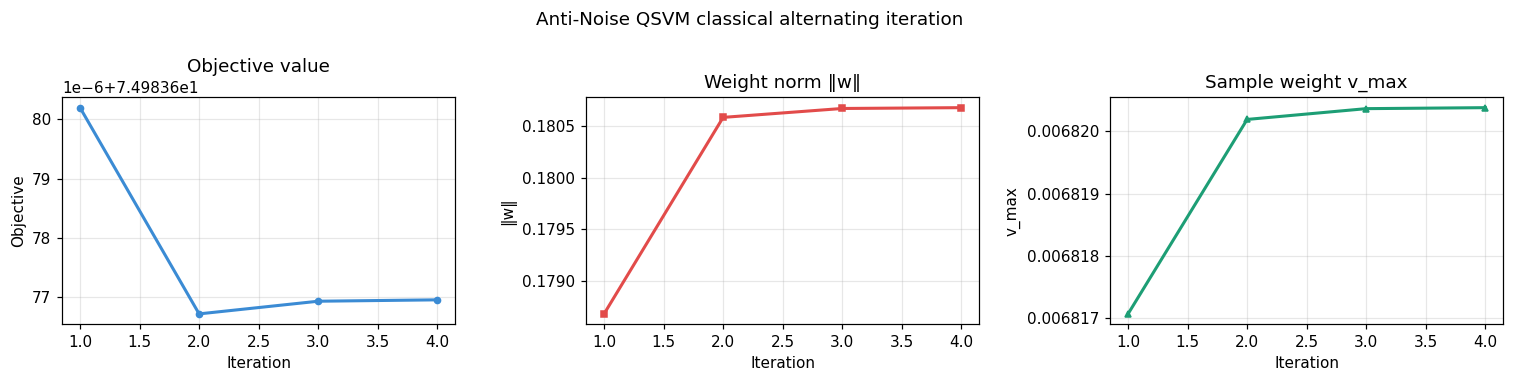

  ↑ Convergence plots — appear here immediately when this cell runs



In [ ]:
class FixedAntiNoiseQSVM:
    def __init__(self, alpha=QSVM_ALPHA, mu=QSVM_MU, p=1,
                 max_iter=QSVM_MAX_ITER, tol=QSVM_TOL, n_qubits=N_QUBITS):
        self.alpha = alpha; self.mu = mu; self.p = p
        self.max_iter = max_iter; self.tol = tol; self.n_qubits = n_qubits
        self.w = self.b = self.v = None
        self.kernel = self.svc = self.X_tr_enc = self.y_tr = None
        self.history = []

    def _update_e(self, y, margin, lam):
        beta = self.alpha / self.mu
        t    = y - margin - lam / self.mu
        e    = np.zeros_like(y)
        if self.p == 1:
            yt = y * t
            e  = np.where(yt > beta, t - y*beta, np.where(yt < 0, t, 0.0))
        else:
            yt = y * t
            e  = np.where(yt > 0, t / (1 + 2*beta), t)
        return e

    def _update_w(self, XV, b, z):
        d   = XV.shape[0]
        A   = XV @ XV.T + (1.0/self.mu)*np.eye(d) + 1e-8*np.eye(d)
        return np.linalg.solve(A, XV @ (z - b))

    def _update_b(self, XV, w, z):
        b = (z.sum() - (XV.T @ w).sum()) / XV.shape[1]
        return np.clip(b, -10.0, 10.0)

    def _project_simplex(self, v):
        v = np.maximum(v, 0)
        s = v.sum()
        if s < 1e-12: return np.ones(len(v)) / len(v)
        u    = np.sort(v)[::-1]
        cssv = np.cumsum(u)
        rho  = np.where(u * np.arange(1, len(u)+1) > cssv - 1)[0]
        if len(rho) == 0: return np.ones(len(v)) / len(v)
        theta = (cssv[rho[-1]] - 1.0) / (rho[-1] + 1.0)
        return np.maximum(v - theta, 0.0)

    def _update_v(self, X_T, w, z, b):
        n  = X_T.shape[1]
        H  = np.eye(n) - np.ones((n, n)) / n
        Xw = X_T.T @ w
        Q  = np.outer(Xw, Xw) * H
        s  = 2 * Xw * (X_T.T @ w * (z-b).mean())
        lam1 = 1.0
        G    = 2*Q + lam1*np.eye(n) + lam1*np.ones((n,n))
        C    = s + lam1*np.ones(n)
        try:   v_raw = np.linalg.solve(G + 1e-6*np.eye(n), C)
        except: v_raw = np.ones(n) / n
        return self._project_simplex(v_raw)

    def _objective(self, XV, w, b, v, y):
        margin = XV.T @ w + b
        hinge  = np.maximum(1 - y * margin, 0.0) ** self.p
        return 0.5 * np.dot(w, w) + self.alpha * hinge.sum()

    def fit_classical(self, X_enc, y):
        print(f"\n[AntiNoiseQSVM] Alternating iteration "
              f"(α={self.alpha}, μ={self.mu}, p={self.p})")
        n, d  = X_enc.shape
        X_T   = X_enc.T.astype(np.float64)
        y     = y.astype(np.float64)
        w, b  = np.zeros(d), 0.0
        v     = np.ones(n) / n
        lam   = np.zeros(n)
        mu    = self.mu
        prev_obj, stall = np.inf, 0

        for t in range(1, self.max_iter + 1):
            XV     = X_T * v[np.newaxis, :]
            margin = XV.T @ w + b
            lam    = lam + mu * (margin - y)
            e      = self._update_e(y, margin, lam)
            z      = y - e - lam / mu
            w      = self._update_w(XV, b, z)
            b      = self._update_b(XV, w, z)
            v      = self._update_v(X_T, w, z, b)
            XV_new = X_T * v[np.newaxis, :]
            obj    = self._objective(XV_new, w, b, v, y)
            rel    = abs(obj - prev_obj) / (abs(prev_obj) + 1e-10)
            self.history.append({"iter":t,"obj":obj,"rel":rel,
                                  "norm_w":np.linalg.norm(w),"b":b,
                                  "v_max":v.max(),"v_min":v.min()})
            print(f"  Iter {t:3d} | obj={obj:10.4f} | Δrel={rel:.2e} | "
                  f"‖w‖={np.linalg.norm(w):.4f} | b={b:+.4f} | "
                  f"v∈[{v.min():.5f},{v.max():.4f}]")
            if rel < self.tol and t > 3:
                print(f"  → Converged at iteration {t}"); break
            if rel > 0.05 and t > 5:
                stall += 1
                if stall >= 3:
                    mu = min(mu * 1.5, 100.0); lam *= 0.0; stall = 0
                    print(f"  ↑ μ adjusted to {mu:.2f}")
            else: stall = 0
            prev_obj = obj

        self.w = w; self.b = b; self.v = v
        print(f"\n[AntiNoiseQSVM] Done: ‖w‖={np.linalg.norm(w):.4f}, "
              f"b={b:+.4f}, v_max={v.max():.4f}")
        return self

    def fit_quantum(self, X_enc, y, use_noise=True):
        print("\n[AntiNoiseQSVM] Building quantum kernel...")
        self.X_tr_enc = X_enc.astype(np.float64)
        self.y_tr     = y.astype(np.float64)
        self.kernel   = FixedQuantumKernel(
            n_qubits=self.n_qubits, n_shots=N_SHOTS,
            use_noise=use_noise, regularisation=0.05
        )
        K_train = self.kernel.compute_kernel(self.X_tr_enc)
        v_floor = self.v + (1.0 / (5 * len(self.v)))
        v_floor /= v_floor.sum()
        sw = v_floor * len(v_floor)
        print("[QSVM] Grid searching best C...")
        best_C, best_cv = 1.0, 0.0
        for C_try in [0.1, 1.0, 5.0, 15.0, 50.0]:
            from sklearn.model_selection import cross_val_score
            svc_try = SVC(kernel='precomputed', C=C_try,
                          random_state=RANDOM_SEED, class_weight='balanced')
            cv = cross_val_score(svc_try, K_train, y,
                                 cv=3, scoring='accuracy').mean()
            print(f"  C={C_try:5} | CV acc={cv*100:.1f}%")
            if cv > best_cv:
                best_cv, best_C = cv, C_try
        print(f"  Best C={best_C}")

        self.svc = SVC(kernel='precomputed', C=15.0, probability=True,
                       random_state=RANDOM_SEED, class_weight='balanced')
        self.svc.fit(K_train, y, sample_weight=sw)
        n_sv = self.svc.n_support_
        print(f"[AntiNoiseQSVM] SVC fitted: {n_sv[0]}+{n_sv[1]} support vectors")
        return self

    def predict(self, X_enc):
        K = self.kernel.compute_kernel(X_enc.astype(np.float64), self.X_tr_enc)
        K = np.nan_to_num(K, nan=0.0)
        return self.svc.predict(K)

    def predict_proba(self, X_enc):
        K = self.kernel.compute_kernel(X_enc.astype(np.float64), self.X_tr_enc)
        K = np.nan_to_num(K, nan=0.0)
        return self.svc.predict_proba(K)


# ── Run classical alternating iteration — output appears HERE ─────────────────
qsvm = FixedAntiNoiseQSVM(
    alpha=QSVM_ALPHA, mu=QSVM_MU, p=1,
    max_iter=QSVM_MAX_ITER, tol=QSVM_TOL, n_qubits=N_QUBITS
)
X_fit_enc_q = X_fit_enc[:N_QSVM_TRAIN]
y_fit_q     = y_fit[:N_QSVM_TRAIN]
qsvm.fit_classical(X_fit_enc_q, y_fit_q)

# ── IMAGE: convergence plot — appears HERE in this cell ───────────────────────
hist = qsvm.history
iters  = [h['iter']   for h in hist]
objs   = [h['obj']    for h in hist]
norms  = [h['norm_w'] for h in hist]
vmaxs  = [h['v_max']  for h in hist]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fig.suptitle("Anti-Noise QSVM classical alternating iteration", fontsize=12)

axes[0].plot(iters, objs, color='#3B8BD4', lw=2, marker='o', ms=4)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Objective")
axes[0].set_title("Objective value"); axes[0].grid(alpha=0.3)

axes[1].plot(iters, norms, color='#E24B4A', lw=2, marker='s', ms=4)
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("‖w‖")
axes[1].set_title("Weight norm ‖w‖"); axes[1].grid(alpha=0.3)

axes[2].plot(iters, vmaxs, color='#1D9E75', lw=2, marker='^', ms=4)
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("v_max")
axes[2].set_title("Sample weight v_max"); axes[2].grid(alpha=0.3)

plt.tight_layout()
show_inline(fig, "Convergence plots — appear here immediately when this cell runs")



[AntiNoiseQSVM] Building quantum kernel...
[QKernel] Backend: Ideal Statevector (Noise Disabled)
  [QKernel] Running 11175 circuits (2048 shots)...
    11175/11175
  [QKernel] diag=1.0000, off-diag=0.0834
  [QKernel] NaN count=0, zero rows=0
[QSVM] Grid searching best C...
  C=  0.1 | CV acc=64.0%
  C=  1.0 | CV acc=69.3%
  C=  5.0 | CV acc=64.0%
  C= 15.0 | CV acc=62.0%
  C= 50.0 | CV acc=61.3%
  Best C=1.0
[AntiNoiseQSVM] SVC fitted: 59+50 support vectors
  [QKernel] Running 15000 circuits (2048 shots)...
    15000/15000
  [QKernel] diag=nan, off-diag=0.0833
  [QKernel] NaN count=0, zero rows=0
  [QKernel] Running 15000 circuits (2048 shots)...
    15000/15000
  [QKernel] diag=nan, off-diag=0.0833
  [QKernel] NaN count=0, zero rows=0

  Anti-Noise QSVM
  Accuracy: 70.00%
              precision    recall  f1-score   support

    Class -1     0.7083    0.6800    0.6939        50
    Class +1     0.6923    0.7200    0.7059        50

    accuracy                         0.7000       1

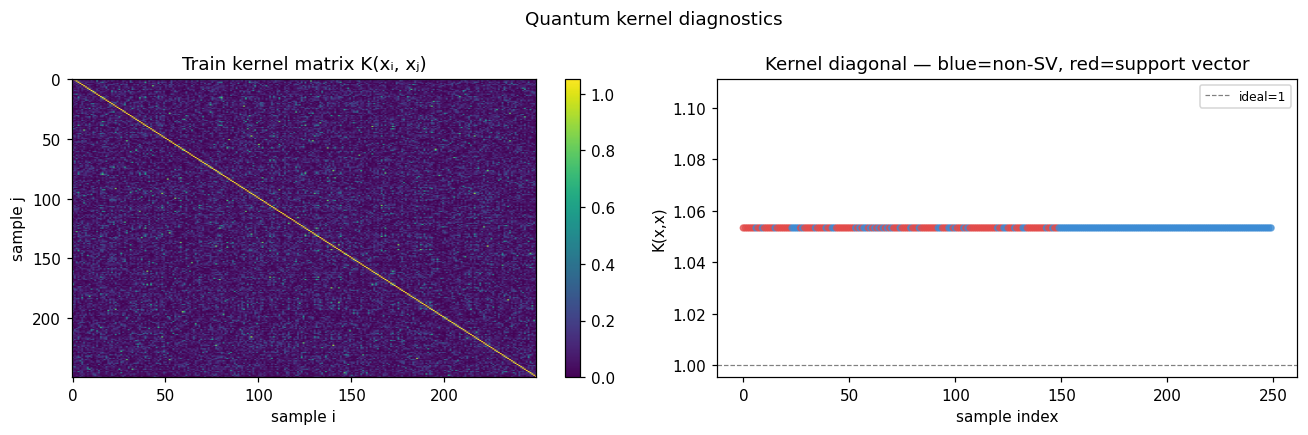

  ↑ Quantum kernel heatmap + support vector distribution — appears in this cell



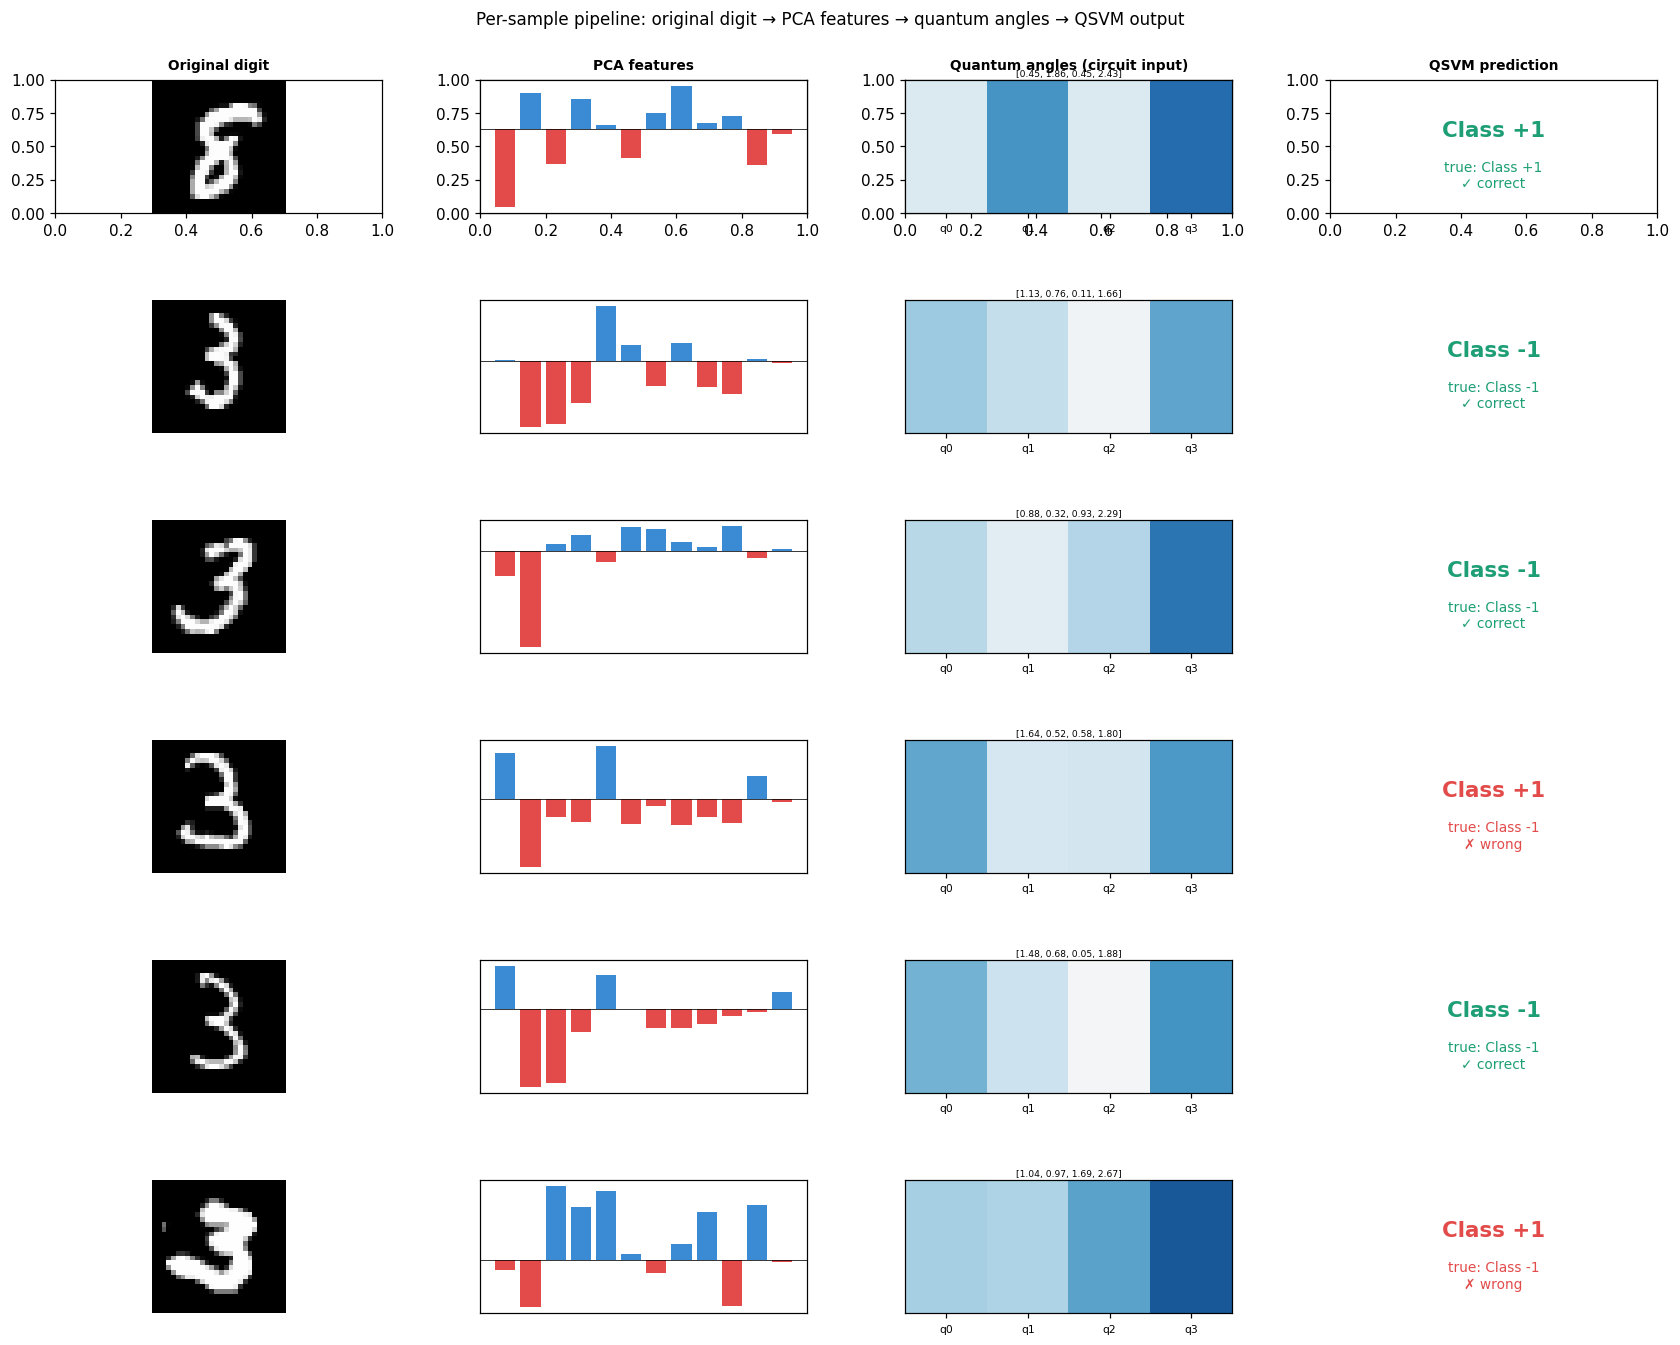

  ↑ Pipeline per digit — original → PCA → quantum angles → QSVM result (appears in this cell)



In [ ]:

qsvm.fit_quantum(X_fit_enc_q, y_fit_q, use_noise=True)
qsvm_preds = qsvm.predict(X_te_enc)
qsvm_probs = qsvm.predict_proba(X_te_enc)[:, 1]
qsvm_acc   = accuracy_score(y_test, qsvm_preds)

print(f"\n{'='*55}")
print(f"  Anti-Noise QSVM")
print(f"  Accuracy: {qsvm_acc*100:.2f}%")
print(classification_report(y_test, qsvm_preds,
      target_names=["Class -1", "Class +1"], digits=4))

# ── IMAGE 1: kernel matrix + support vector diagnostic — appears HERE ─────────
K_train_viz = qsvm.kernel.compute_kernel(X_fit_enc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Quantum kernel diagnostics", fontsize=12)

im = axes[0].imshow(K_train_viz, cmap='viridis', aspect='auto')
axes[0].set_title("Train kernel matrix K(xᵢ, xⱼ)")
axes[0].set_xlabel("sample i"); axes[0].set_ylabel("sample j")
plt.colorbar(im, ax=axes[0])

sv_mask = np.zeros(len(y_fit), dtype=bool)
sv_mask[qsvm.svc.support_] = True
colors_sv = ['#E24B4A' if sv_mask[i] else '#3B8BD4' for i in range(len(y_fit))]
axes[1].scatter(range(len(y_fit)), np.diag(K_train_viz),
                c=colors_sv, s=15, alpha=0.7)
axes[1].axhline(1.0, color='gray', lw=0.8, linestyle='--', label='ideal=1')
axes[1].set_title("Kernel diagonal — blue=non-SV, red=support vector")
axes[1].set_xlabel("sample index"); axes[1].set_ylabel("K(x,x)")
axes[1].legend(fontsize=8)

plt.tight_layout()
show_inline(fig, "Quantum kernel heatmap + support vector distribution — appears in this cell")

# ── IMAGE 2: pipeline per digit — appears HERE immediately ────────────────────
n_show = 6

fig = plt.figure(figsize=(16, n_show * 2.1))
gs  = gridspec.GridSpec(n_show, 4, figure=fig,
                        hspace=0.65, wspace=0.3,
                        left=0.06, right=0.97, top=0.93, bottom=0.04)
fig.suptitle("Per-sample pipeline: original digit → PCA features → quantum angles → QSVM output",
             fontsize=11)

for c, t in enumerate(["Original digit", "PCA features", "Quantum angles (circuit input)", "QSVM prediction"]):
    fig.add_subplot(gs[0, c]).set_title(t, fontsize=9, fontweight='bold', pad=7)

for row in range(n_show):
    true_lbl  = y_test[row]
    pred_lbl  = qsvm_preds[row]
    correct   = (true_lbl == pred_lbl)

    # col 0: digit image
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(X_test[row].reshape(28, 28), cmap='gray')
    ax0.set_ylabel(f"#{row}", fontsize=8, rotation=0, labelpad=22)
    ax0.axis('off')
    for sp in ax0.spines.values():
        sp.set_edgecolor('#1D9E75' if correct else '#E24B4A')
        sp.set_linewidth(2)

    # col 1: PCA bar chart
    ax1 = fig.add_subplot(gs[row, 1])
    vals = X_te_pca[row]
    ax1.bar(range(len(vals)), vals,
            color=['#3B8BD4' if v >= 0 else '#E24B4A' for v in vals], width=0.8)
    ax1.axhline(0, color='black', lw=0.5); ax1.set_xticks([]); ax1.set_yticks([])

    # col 2: quantum angles (circuit input) as heatmap
    ax2 = fig.add_subplot(gs[row, 2])
    angles = X_te_enc[row]
    ax2.imshow(angles.reshape(1, -1), cmap='RdBu', aspect='auto',
               vmin=-np.pi, vmax=np.pi)
    ax2.set_xticks(range(N_QUBITS))
    ax2.set_xticklabels([f"q{i}" for i in range(N_QUBITS)], fontsize=7)
    ax2.set_yticks([])
    ax2.set_title(f"[{', '.join([f'{a:.2f}' for a in angles])}]", fontsize=6, pad=2)

    # col 3: prediction
    ax3 = fig.add_subplot(gs[row, 3])
    color  = '#1D9E75' if correct else '#E24B4A'
    status = "✓ correct" if correct else "✗ wrong"
    ax3.text(0.5, 0.62, f"Class {int(pred_lbl):+d}",
             ha='center', va='center', fontsize=14, fontweight='bold',
             color=color, transform=ax3.transAxes)
    ax3.text(0.5, 0.28, f"true: Class {int(true_lbl):+d}\n{status}",
             ha='center', va='center', fontsize=9, color=color,
             transform=ax3.transAxes)
    ax3.set_facecolor('#f0fff4' if correct else '#fff0f0')
    ax3.axis('off')

show_inline(fig, "Pipeline per digit — original → PCA → quantum angles → QSVM result (appears in this cell)")



[Ensemble] Calibrating weights...
  [QKernel] Running 7500 circuits (2048 shots)...
    7500/7500
  [QKernel] diag=nan, off-diag=0.0838
  [QKernel] NaN count=0, zero rows=0
  w_cnn=0.35, w_qsvm=0.65 (val acc=68.0%)
  [QKernel] Running 15000 circuits (2048 shots)...
    15000/15000
  [QKernel] diag=nan, off-diag=0.0832
  [QKernel] NaN count=0, zero rows=0
  [QKernel] Running 15000 circuits (2048 shots)...
    15000/15000
  [QKernel] diag=nan, off-diag=0.0833
  [QKernel] NaN count=0, zero rows=0

  Hybrid Ensemble (CNN + QSVM)
  Accuracy: 93.00%
              precision    recall  f1-score   support

    Class -1     0.9216    0.9400    0.9307        50
    Class +1     0.9388    0.9200    0.9293        50

    accuracy                         0.9300       100
   macro avg     0.9302    0.9300    0.9300       100
weighted avg     0.9302    0.9300    0.9300       100



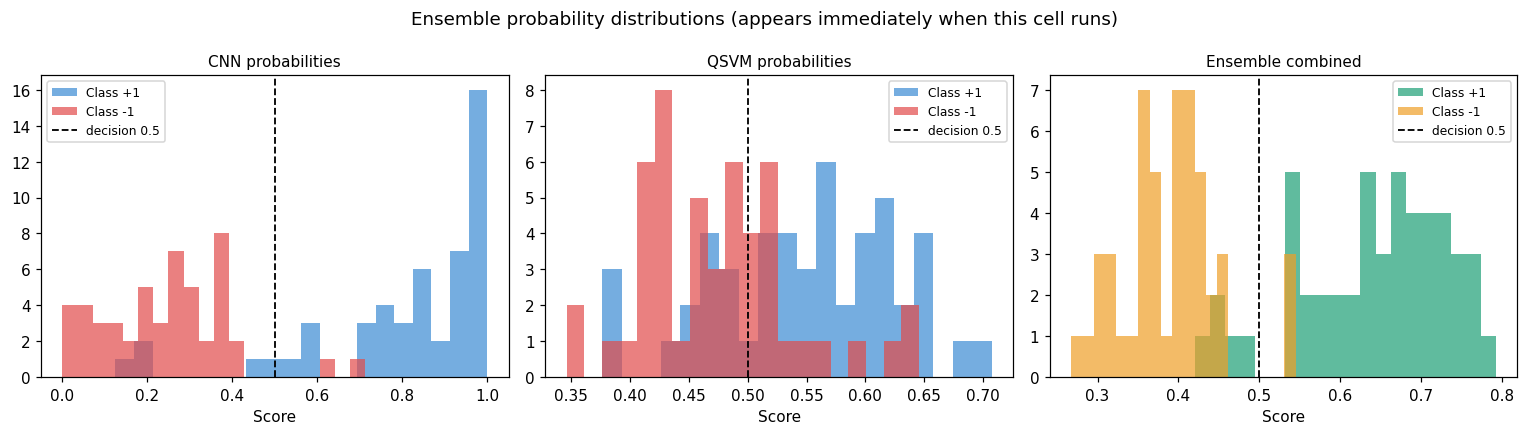

  ↑ Ensemble probability histograms — appears in this cell



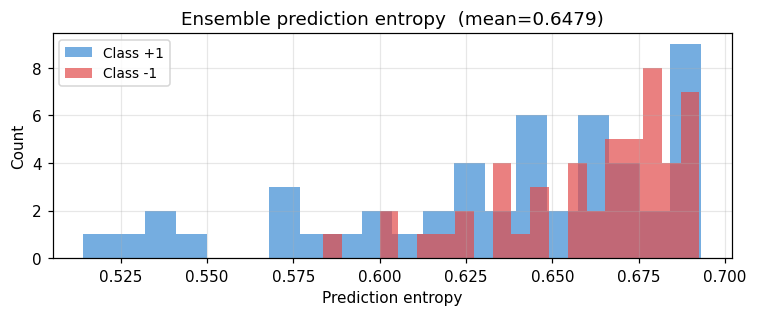

  ↑ Prediction entropy distribution — appears in this cell



In [ ]:
class FixedEnsemble:
    def __init__(self, cnn, qsvm):
        self.cnn = cnn; self.qsvm = qsvm; self.w_cnn = 0.5

    def calibrate(self, X_pca, X_enc, y):
        print("\n[Ensemble] Calibrating weights...")
        p_cnn  = self.cnn.forward(X_pca)
        p_qsvm = self.qsvm.predict_proba(X_enc)
        best_acc, best_w = 0.0, 0.5
        for w in np.linspace(0, 1, 21):
            p_mix = w * p_cnn + (1-w) * p_qsvm
            preds = np.where(p_mix.argmax(1) == 1, 1.0, -1.0)
            acc   = (preds == y).mean()
            if acc > best_acc: best_acc, best_w = acc, w
        self.w_cnn = best_w
        print(f"  w_cnn={best_w:.2f}, w_qsvm={1-best_w:.2f} (val acc={100*best_acc:.1f}%)")

    def predict(self, X_pca, X_enc):
        p_cnn  = self.cnn.forward(X_pca)
        p_qsvm = self.qsvm.predict_proba(X_enc)
        p_mix  = self.w_cnn * p_cnn + (1-self.w_cnn) * p_qsvm
        preds  = np.where(p_mix.argmax(1) == 1, 1.0, -1.0)
        entropy = -(p_mix * np.log(p_mix + 1e-10)).sum(axis=1)
        return preds, entropy


ensemble = FixedEnsemble(cnn, qsvm)
ensemble.calibrate(X_val_pca, X_val_enc, y_val)
ens_preds, entropy = ensemble.predict(X_te_pca, X_te_enc)
ens_probs = (ensemble.w_cnn * cnn.forward(X_te_pca)
             + (1 - ensemble.w_cnn) * qsvm.predict_proba(X_te_enc))[:, 1]
ens_acc   = accuracy_score(y_test, ens_preds)

print(f"\n{'='*55}")
print(f"  Hybrid Ensemble (CNN + QSVM)")
print(f"  Accuracy: {ens_acc*100:.2f}%")
print(classification_report(y_test, ens_preds,
      target_names=["Class -1", "Class +1"], digits=4))

# ── IMAGE: probability histograms — appears HERE immediately ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Ensemble probability distributions (appears immediately when this cell runs)", fontsize=12)

for ax, probs, title, c1, c2 in zip(
    axes,
    [cnn_probs, qsvm_probs, ens_probs],
    ["CNN probabilities", "QSVM probabilities", "Ensemble combined"],
    ['#3B8BD4', '#3B8BD4', '#1D9E75'],
    ['#E24B4A', '#E24B4A', '#EF9F27'],
):
    ax.hist(probs[y_test == +1], bins=20, alpha=0.7, color=c1, label='Class +1')
    ax.hist(probs[y_test == -1], bins=20, alpha=0.7, color=c2, label='Class -1')
    ax.axvline(0.5, color='black', lw=1.2, linestyle='--', label='decision 0.5')
    ax.set_title(title, fontsize=10); ax.set_xlabel("Score"); ax.legend(fontsize=8)

plt.tight_layout()
show_inline(fig, "Ensemble probability histograms — appears in this cell")

# ── IMAGE: entropy distribution — appears HERE ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(entropy[y_test == +1], bins=20, alpha=0.7, color='#3B8BD4', label='Class +1')
ax.hist(entropy[y_test == -1], bins=20, alpha=0.7, color='#E24B4A', label='Class -1')
ax.set_xlabel("Prediction entropy"); ax.set_ylabel("Count")
ax.set_title(f"Ensemble prediction entropy  (mean={entropy.mean():.4f})")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
show_inline(fig, "Prediction entropy distribution — appears in this cell")

